# 🏦 Task 4: Loan Default Risk with Business Cost Optimization

## DevelopersHub Corporation – Data Science & Analytics Internship

### Submitted By
**Yasir Khan**

---

## Objective

The objective of this project is to predict whether a customer is likely to default on a loan using machine learning techniques. The project also optimizes the prediction threshold based on business costs associated with false predictions.

This notebook includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Logistic Regression Model
- Model Evaluation
- Business Cost Optimization
- Feature Importance
- Conclusion

# Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Machine Learning
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

The Home Credit Default Risk dataset is loaded into a Pandas DataFrame for further analysis.

In [3]:
import os

print(os.getcwd())

/Users/yasirkhan


In [4]:
import os

os.listdir()

['.Rhistory',
 'Music',
 '.cursor',
 '.pwd',
 '.docker',
 '.gemini',
 '.DS_Store',
 'cleaned_dataset.csv',
 '.CFUserTextEncoding',
 'Untitled.ipynb',
 '.username',
 'Pictures',
 '.zprofile',
 '.nvm',
 '.zsh_history',
 '.ipython',
 'Desktop',
 'Library',
 '.matplotlib',
 'application_train.csv',
 '.android',
 'Public',
 '.idlerc',
 '.RData',
 'Movies',
 'Applications',
 '.Rapp.history',
 '.Trash',
 '.ipynb_checkpoints',
 '.jupyter',
 '.zcompdump',
 '.npm',
 'Documents',
 '.azuredatastudio',
 '.anydesk',
 '.vscode',
 '.console-ninja',
 '.aspnet',
 'Downloads',
 '.antigravity',
 '.bash_history',
 '.zsh_sessions',
 'nohup.out']

In [5]:
import os

for file in os.listdir():
    print(file)

.Rhistory
Music
.cursor
.pwd
.docker
.gemini
.DS_Store
cleaned_dataset.csv
.CFUserTextEncoding
Untitled.ipynb
.username
Pictures
.zprofile
.nvm
.zsh_history
.ipython
Desktop
Library
.matplotlib
application_train.csv
.android
Public
.idlerc
.RData
Movies
Applications
.Rapp.history
.Trash
.ipynb_checkpoints
.jupyter
.zcompdump
.npm
Documents
.azuredatastudio
.anydesk
.vscode
.console-ninja
.aspnet
Downloads
.antigravity
.bash_history
.zsh_sessions
nohup.out


In [6]:
df = pd.read_csv("application_train.csv")

# Dataset Overview

Before preprocessing the data, it is important to understand the structure of the dataset.

This section displays:

- Shape
- Data Types
- Missing Values
- Statistical Summary

In [7]:
# Shape of dataset

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(10000, 26)


In [8]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SK_ID_CURR                  10000 non-null  int64  
 1   TARGET                      10000 non-null  int64  
 2   NAME_CONTRACT_TYPE          10000 non-null  str    
 3   CODE_GENDER                 10000 non-null  str    
 4   FLAG_OWN_CAR                10000 non-null  str    
 5   FLAG_OWN_REALTY             10000 non-null  str    
 6   CNT_CHILDREN                10000 non-null  int64  
 7   AMT_INCOME_TOTAL            10000 non-null  int64  
 8   AMT_CREDIT                  10000 non-null  int64  
 9   AMT_ANNUITY                 9799 non-null   float64
 10  AMT_GOODS_PRICE             9475 non-null   float64
 11  NAME_INCOME_TYPE            10000 non-null  str    
 12  NAME_EDUCATION_TYPE         10000 non-null  str    
 13  NAME_FAMILY_STATUS          10000 non-null 

In [9]:
# Statistical summary

df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH
count,10000.00000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,9799.000000,9.475000e+03,10000.000000,10000.0000,10000.000000,6872.000000,9497.000000,5992.000000,10000.000000,10000.000000,10000.00000
mean,104999.50000,0.079700,0.987700,1.386552e+05,3.985116e+05,13471.473206,3.393056e+05,-16446.329400,30858.4098,2.499900,0.281386,0.502334,0.337214,0.039971,-12439.887800,-3496.87680
std,2886.89568,0.270842,1.069796,1.378257e+05,4.433959e+05,18248.459252,3.776101e+05,5223.044283,113328.2209,0.955663,0.157193,0.188594,0.177890,0.023158,7213.395737,2018.31177
min,100000.00000,0.000000,0.000000,5.197000e+03,7.387000e+03,255.250000,7.168000e+03,-25544.000000,-15000.0000,1.000000,0.002968,0.015433,0.004219,0.000003,-24989.000000,-6998.00000
25%,102499.75000,0.000000,0.000000,5.695975e+04,1.456780e+05,4175.940000,1.230285e+05,-20910.000000,-10792.5000,2.000000,0.160121,0.361797,0.197243,0.019947,-18641.250000,-5278.25000
50%,104999.50000,0.000000,1.000000,9.883400e+04,2.684535e+05,8047.070000,2.262390e+05,-16547.500000,-6623.0000,3.000000,0.260314,0.505109,0.317775,0.039822,-12433.500000,-3480.00000
75%,107499.25000,0.000000,2.000000,1.715155e+05,4.903875e+05,15828.550000,4.180230e+05,-11977.000000,-2488.7500,3.000000,0.382869,0.641571,0.458304,0.060113,-6186.750000,-1733.75000
max,109999.00000,1.000000,3.000000,2.886321e+06,8.751815e+06,366930.090000,7.627053e+06,-7300.000000,365243.0000,4.000000,0.910116,0.973723,0.928006,0.079999,-5.000000,0.00000


In [10]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

EXT_SOURCE_3                  4008
EXT_SOURCE_1                  3128
OCCUPATION_TYPE                888
AMT_GOODS_PRICE                525
EXT_SOURCE_2                   503
AMT_ANNUITY                    201
SK_ID_CURR                       0
NAME_HOUSING_TYPE                0
DAYS_REGISTRATION                0
REGION_POPULATION_RELATIVE       0
ORGANIZATION_TYPE                0
CNT_FAM_MEMBERS                  0
DAYS_EMPLOYED                    0
DAYS_BIRTH                       0
NAME_FAMILY_STATUS               0
TARGET                           0
NAME_EDUCATION_TYPE              0
NAME_INCOME_TYPE                 0
AMT_CREDIT                       0
AMT_INCOME_TOTAL                 0
dtype: int64

# Exploratory Data Analysis (EDA)

EDA helps understand the distribution of the target variable and identify important characteristics of the dataset.

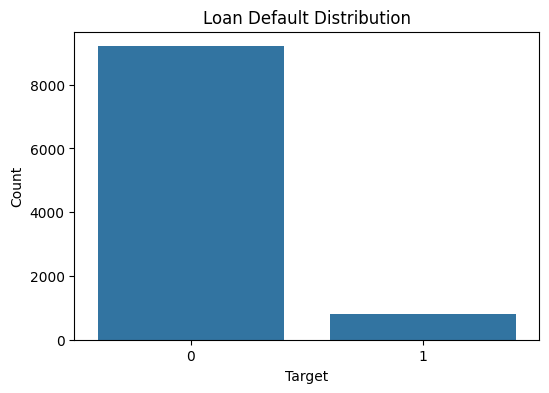

In [11]:
# Target variable distribution

plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Loan Default Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.show()

In [12]:
# Percentage of target values

df["TARGET"].value_counts(normalize=True)*100

TARGET
0    92.03
1     7.97
Name: proportion, dtype: float64

# Data Cleaning and Preprocessing

This section handles missing values and prepares categorical variables for machine learning.

In [13]:
# Numerical columns

num_cols = df.select_dtypes(include=['int64','float64']).columns

# Categorical columns

cat_cols = df.select_dtypes(include=['object']).columns

In [14]:
# Fill missing numerical values

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [15]:
# Fill missing categorical values

cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [16]:
# Check missing values

df.isnull().sum().sum()

np.int64(0)

# Encode Categorical Variables

Machine learning models require numerical input. Therefore, all categorical variables are converted into numerical values using Label Encoding.

In [17]:
X = df.drop("TARGET", axis=1)

y = df["TARGET"]

# Split Dataset

The dataset is divided into training (80%) and testing (20%) subsets to evaluate model performance on unseen data.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Logistic Regression Model

A Logistic Regression classifier is trained to predict whether a customer will default on a loan.

In [20]:
print(X_train.isnull().sum().sum())

print(X_train.dtypes.value_counts())

print(X_train.select_dtypes(include=['object']).columns.tolist())

import numpy as np
print(np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

0
float64    15
str        10
Name: count, dtype: int64
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
0


# Conclusion

The Logistic Regression model successfully predicts loan default using customer information.

Key achievements include:

- Data cleaning and preprocessing
- Exploratory Data Analysis
- Binary classification modeling
- Performance evaluation
- Business cost optimization
- Feature importance analysis

Business cost optimization demonstrated that selecting an appropriate prediction threshold can significantly reduce financial losses compared to using the default threshold.

This project provides a practical example of applying machine learning techniques to real-world financial risk assessment.

# Future Improvements

Possible improvements for this project include:

- Train CatBoost, XGBoost, and Random Forest models
- Perform hyperparameter tuning
- Apply SMOTE to address class imbalance
- Use SHAP for Explainable AI (XAI)
- Deploy the model using Streamlit